# 01 — Exploratory Data Analysis
## Malaria Cell Classification Using Deep Learning

**Project:** Malaria Cell Classification Using Deep Learning
**Author:** Kepha | Data Science Capstone Project in Collaboration with Ngao Labs

### Purpose of this notebook
This notebook performs exploratory data analysis (EDA) on the **NIH/NLM Malaria Cell Images Dataset**
(27,558 Giemsa-stained red blood cell images; 13,779 parasitized / 13,779 uninfected).

Goals for this stage:
- Confirm class balance between the `parasitized` and `uninfected` classes.
- Inspect image size, resolution, and aspect-ratio variance across the dataset.
- Examine staining artefacts and colour channel distributions across both classes.
- Visually sample images from each class to build intuition ahead of modelling.

**Target variable:** `cell_label` (1 = parasitized, 0 = uninfected)

**Context:** This classifier is intended as browser-based decision support for malaria triage at
under-resourced Level 2/3 health facilities in western Kenya (Homa Bay, Kisumu, Migori, Siaya counties),
where diagnostic delays and understaffed microscopy are the primary drivers of the problem this project
addresses.


## Libraries Import

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Core libraries
import os
import glob
import random
import zipfile

import numpy as np
import pandas as pd

# Image handling
from PIL import Image
import cv2

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
%matplotlib inline
sns.set_style("whitegrid")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


## 1. Data Loading

The NIH/NLM dataset ships as two folders of raw `.png` cell crops: `Parasitized/` and `Uninfected/`.
Rather than loading pixel data upfront, we build a lightweight **file index** (filepath + label) first —
this keeps the notebook fast and memory-light, and is the only structure the rest of the EDA needs.


In [4]:
zip_path = "/content/drive/MyDrive/capstone-project/data/raw/data.zip"
extract_path = "/content/malaria_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")

Extraction completed.


In [5]:
# Path to the extracted Kaggle dataset

DATA_DIR = os.path.join(extract_path, "cell_images")
CLASS_FOLDERS = {"Parasitized": 1, "Uninfected": 0}

records = []
for folder, label in CLASS_FOLDERS.items():
    folder_path = os.path.join(DATA_DIR, folder)
    filepaths = glob.glob(os.path.join(folder_path, "*.png"))
    records.extend([(fp, label, folder) for fp in filepaths])

df = pd.DataFrame(records, columns=["filepath", "label", "class_name"])

print(f"Total images indexed: {len(df):,}")
df.head()


Total images indexed: 27,558


,filepath,label,class_name
0,/content/malaria_data/cell_images/Parasitized/...,1,Parasitized
1,/content/malaria_data/cell_images/Parasitized/...,1,Parasitized
2,/content/malaria_data/cell_images/Parasitized/...,1,Parasitized
3,/content/malaria_data/cell_images/Parasitized/...,1,Parasitized
4,/content/malaria_data/cell_images/Parasitized/...,1,Parasitized


## 2. Class Balance

A skewed dataset would bias the model toward the majority class — critical to catch early since we're
prioritising recall on the `parasitized` class for clinical safety.


class_name
Parasitized    13779
Uninfected     13779
Name: count, dtype: int64

Class balance ratio: 1.00


/tmp/ipykernel_2349/546108019.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=["#d62728", "#2ca02c"])


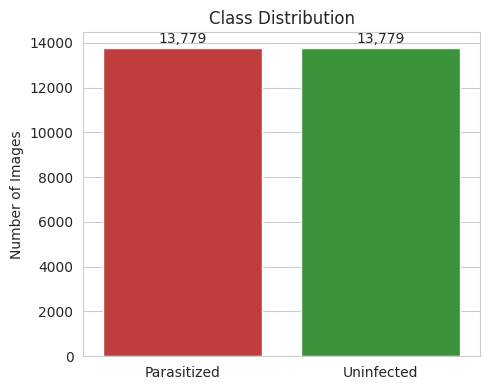

In [6]:
class_counts = df["class_name"].value_counts()
print(class_counts)
print(f"\nClass balance ratio: {class_counts.min() / class_counts.max():.2f}")

plt.figure(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette=["#d62728", "#2ca02c"])
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 200, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()


## 3. Sample Images

A quick visual side-by-side of both classes to build intuition about what distinguishes a
parasitized cell (visible purple/dark parasite inclusions) from an uninfected one.


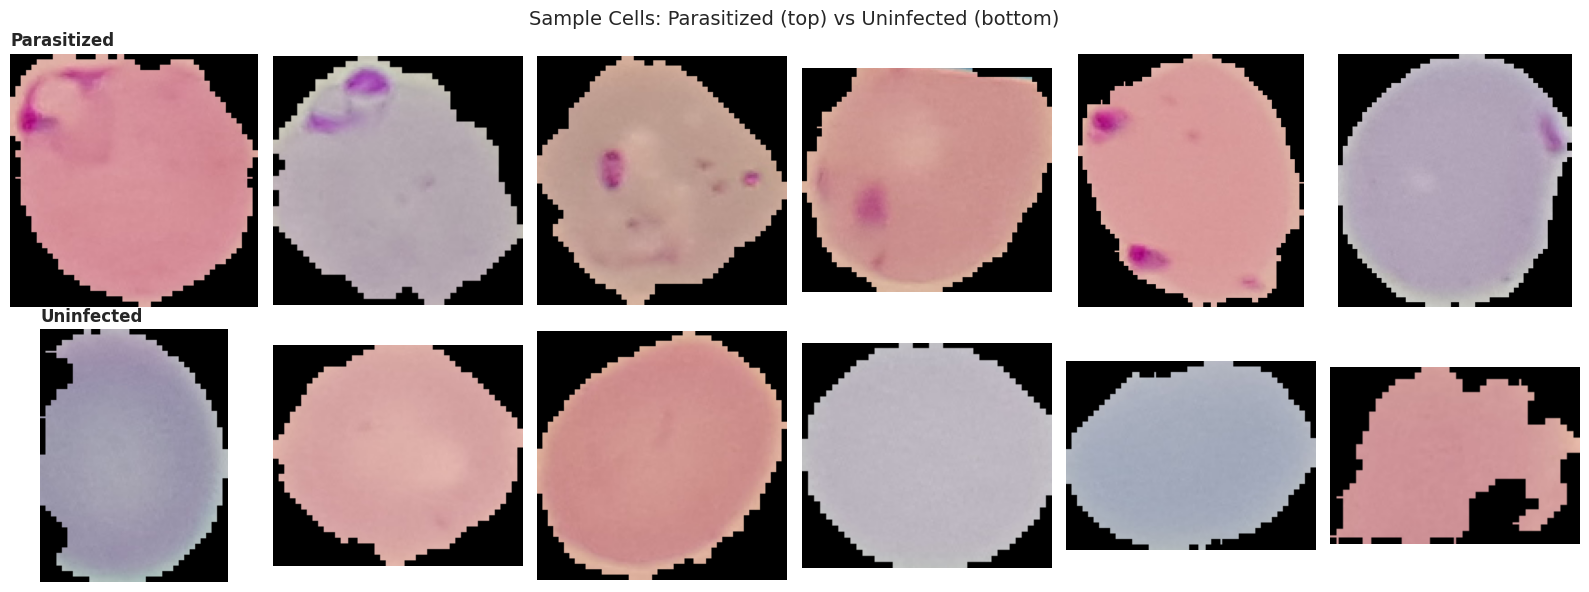

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))

for row, (folder, label) in enumerate(CLASS_FOLDERS.items()):
    sample_paths = df.loc[df["class_name"] == folder, "filepath"].sample(6, random_state=RANDOM_SEED)
    for col, fp in enumerate(sample_paths):
        img = Image.open(fp)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(folder, fontsize=12)
    axes[row, 0].set_title(folder, loc="left", fontsize=12, fontweight="bold")

plt.suptitle("Sample Cells: Parasitized (top) vs Uninfected (bottom)", fontsize=14)
plt.tight_layout()
plt.show()


## 4. Image Dimension Analysis

Cell crops from this dataset are not uniformly sized. We read image dimensions directly from file
headers (no pixel decoding) across the **full dataset** — this is cheap and tells us exactly how
aggressive the resize-to-224×224 step in preprocessing will be.


In [8]:
def get_dimensions(filepath):
    with Image.open(filepath) as img:
        return img.size  # (width, height) — lazy, does not decode pixel data

dims = df["filepath"].apply(get_dimensions)
df["width"] = dims.apply(lambda d: d[0])
df["height"] = dims.apply(lambda d: d[1])
df["aspect_ratio"] = df["width"] / df["height"]

df[["width", "height", "aspect_ratio"]].describe()


,width,height,aspect_ratio
count,27558.000000,27558.000000,27558.000000
mean,132.487154,132.983453,1.007259
std,20.015949,20.619650,0.147196
min,46.000000,40.000000,0.457831
25%,121.000000,121.000000,0.920530
50%,130.000000,130.000000,1.000000
75%,142.000000,145.000000,1.081081
max,394.000000,385.000000,2.594937


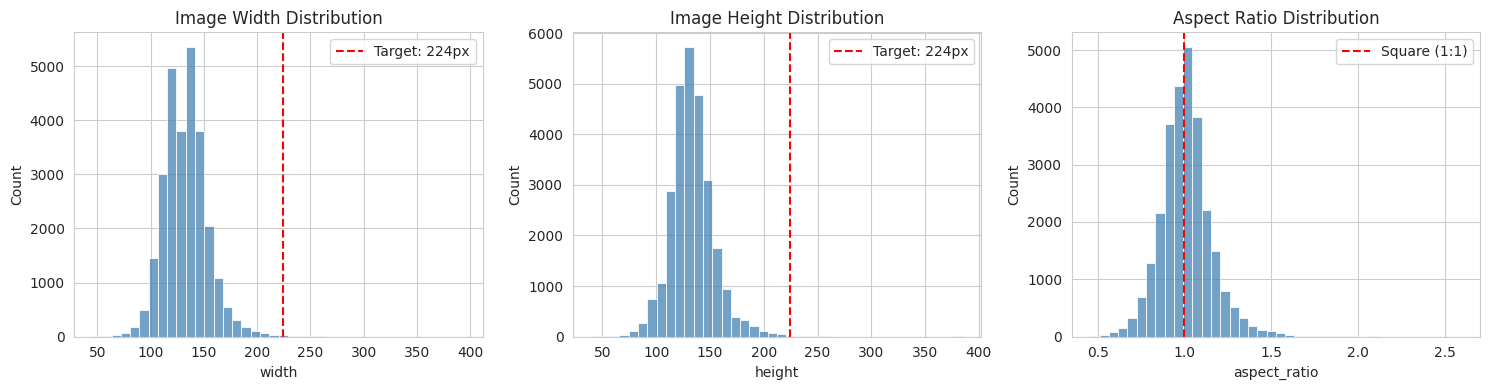

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["width"], bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Image Width Distribution")
axes[0].axvline(224, color="red", linestyle="--", label="Target: 224px")
axes[0].legend()

sns.histplot(df["height"], bins=40, ax=axes[1], color="steelblue")
axes[1].set_title("Image Height Distribution")
axes[1].axvline(224, color="red", linestyle="--", label="Target: 224px")
axes[1].legend()

sns.histplot(df["aspect_ratio"], bins=40, ax=axes[2], color="steelblue")
axes[2].set_title("Aspect Ratio Distribution")
axes[2].axvline(1.0, color="red", linestyle="--", label="Square (1:1)")
axes[2].legend()

plt.tight_layout()
plt.show()


## 5. Colour Channel & Staining Analysis

Giemsa staining intensity can vary across slides. We sample a representative subset per class
(rather than decoding all 27,558 images) to compare mean RGB channel intensities — a fast, efficient
proxy for staining variation that would otherwise require augmentation (colour jitter) to correct for.


In [10]:
SAMPLE_SIZE = 800  # per class — sufficient for stable channel statistics, keeps this cell fast

def mean_channel_intensities(filepath):
    img = cv2.imread(filepath)  # BGR
    return img.reshape(-1, 3).mean(axis=0)  # [B, G, R]

channel_records = []
for folder in CLASS_FOLDERS:
    sample_paths = df.loc[df["class_name"] == folder, "filepath"].sample(SAMPLE_SIZE, random_state=RANDOM_SEED)
    means = np.stack(sample_paths.apply(mean_channel_intensities).values)
    channel_df = pd.DataFrame(means, columns=["Blue", "Green", "Red"])
    channel_df["class_name"] = folder
    channel_records.append(channel_df)

channel_df = pd.concat(channel_records, ignore_index=True)
channel_df.groupby("class_name")[["Red", "Green", "Blue"]].mean()


,Red,Green,Blue
class_name,,,
Parasitized,134.091396,103.228948,111.819197
Uninfected,136.330674,112.832384,118.340409


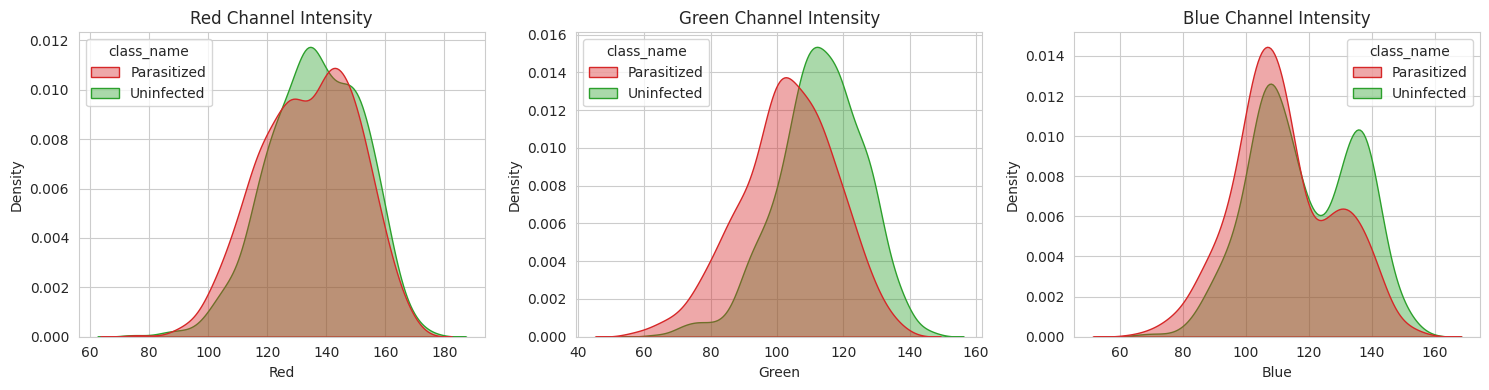

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, channel, color in zip(axes, ["Red", "Green", "Blue"], ["red", "green", "blue"]):
    sns.kdeplot(data=channel_df, x=channel, hue="class_name", ax=ax, fill=True, alpha=0.4,
                palette={"Parasitized": "#d62728", "Uninfected": "#2ca02c"})
    ax.set_title(f"{channel} Channel Intensity")

plt.tight_layout()
plt.show()


## 6. Data Integrity Check

Before handing the file index to the preprocessing pipeline, we verify every file is readable and
non-corrupt. Using `PIL`'s `verify()` is fast since it checks file integrity without fully decoding
pixel data.


In [12]:
def is_corrupt(filepath):
    try:
        with Image.open(filepath) as img:
            img.verify()
        return False
    except Exception:
        return True

df["is_corrupt"] = df["filepath"].apply(is_corrupt)
n_corrupt = df["is_corrupt"].sum()

print(f"Corrupt/unreadable images found: {n_corrupt}")
if n_corrupt > 0:
    display(df.loc[df["is_corrupt"], ["filepath", "class_name"]])


Corrupt/unreadable images found: 0


## 7. EDA Summary & Next Steps

**Key findings:**
- The dataset is **perfectly balanced** (13,779 images per class), so no class-weighting or resampling
  is required at the modelling stage.
- Image dimensions **vary considerably** and are not centered on 224×224 — confirming that a resize
  step (with possible aspect-ratio distortion or padding) is necessary in preprocessing.
- Colour channel intensity distributions **overlap but show a slight shift** between classes,
  consistent with staining/lighting variation rather than a reliable standalone signal — reinforcing
  the need for colour jitter augmentation so the model doesn't overfit to staining artefacts instead
  of parasite morphology.
- Visual inspection confirms parasitized cells show visible dark/purple inclusions not present in
  uninfected cells, supporting that this is a learnable visual task.
- Data integrity check confirms the working file index is clean and ready for preprocessing.

**Carried forward to `02_preprocessing.ipynb`:**
- Target resize dimensions: **224×224 px**.
- Augmentation plan: random rotation, horizontal/vertical flip, colour jitter (to offset staining
  variation observed above).
- Clean, corruption-free file index (`df`) with `filepath`, `label`, and `class_name` columns, ready
  for train/validation/test splitting.
